# Test 3 — A/B-тест: заміна «серця» на «галочку»

**Питання:** впроваджувати нововведення для всіх чи відхилити?

**Як влаштований тест:**
- користувачі з **непарним** `sender_id` бачать нову кнопку («галочка») — це група `test`
- користувачі з **парним** `sender_id` бачать стару («серце») — це група `control`
- тест стартував 24.03.2017 о 16:00

**Метрика:** скільки лайків у середньому ставить один користувач за час тесту.

**План:**
1. Завантажити дані
2. Розділити на «до тесту» і «під час тесту», зібрати групи
3. Перевірити, що групи схожі між собою
4. Порівняти групи
5. Подивитись на графіки й зробити висновок

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Завантаження даних

In [69]:
df = pd.read_csv("../data/test_3/Test_3.csv", sep=';')

# Переводимо дати з тексту у формат дати
df['time_stamp'] = pd.to_datetime(df['time_stamp'], format='%d.%m.%Y %H:%M')
df['reg_date'] = pd.to_datetime(df['reg_date'], format='%d.%m.%Y')

df.head()

,sender_id,platform_id,time_stamp,gender,reg_date
0,3207526951,6,2017-03-16 13:35:00,m,2017-01-26
1,3207526951,6,2017-03-16 09:09:00,m,2017-01-26
2,3207526951,6,2017-03-16 09:09:00,m,2017-01-26
3,3207526951,6,2017-03-16 12:13:00,m,2017-01-26
4,3207526951,6,2017-03-15 14:01:00,m,2017-01-26


In [70]:
print("Рядків (кожен рядок = один лайк):", len(df))
print("Унікальних користувачів:", df['sender_id'].nunique())
print("Період:", df['time_stamp'].min(), "—", df['time_stamp'].max())
print("Платформи (6 = десктоп, 7 = мобільна):", df['platform_id'].value_counts().to_dict())
print("Точних дублікатів рядків:", df.duplicated().sum())

Рядків (кожен рядок = один лайк): 768439
Унікальних користувачів: 26321
Період: 2017-03-13 00:00:00 — 2017-03-27 00:00:00
Платформи (6 = десктоп, 7 = мобільна): {6: 446092, 7: 322347}
Точних дублікатів рядків: 518178


У даних багато повністю однакових рядків. Часу є лише з точністю до хвилини і немає id отримувача, тому не можна сказати, це технічні дублі чи людина реально лайкнула кілька разів за хвилину. Тому **дублікати не видаляємо**.

# 2. Групи та періоди

Тест іде від 24.03 16:00 до кінця даних. «До тесту» беремо такий самий за тривалістю період безпосередньо перед стартом.

In [71]:
TEST_START = pd.Timestamp('2017-03-24 16:00')
TEST_END = df['time_stamp'].max()
duration = TEST_END - TEST_START
PRE_START = TEST_START - duration      # початок періоду «до тесту»

print("Тривалість тесту:", duration)
print("Старт тесту припадає на:", TEST_START.day_name())

# Група: непарний sender_id -> test, парний -> control
df['group'] = np.where(df['sender_id'] % 2 == 1, 'test', 'control')

before = df[(df['time_stamp'] >= PRE_START) & (df['time_stamp'] < TEST_START)]   # до тесту
after = df[df['time_stamp'] >= TEST_START]                                        # під час тесту

Тривалість тесту: 2 days 08:00:00
Старт тесту припадає на: Friday


**Важливо:** тест тривав лише трохи більше двох діб (пʼятниця ввечері — вихідні). Це дуже коротко: не покрито повний тиждень.

## Користувачі для порівняння

Беремо тих, хто ставив хоча б один лайк **до** тесту. Для кожного рахуємо лайки під час тесту. Якщо лайків не було — це **0**, а не пропуск (інакше середнє буде завищене).

In [72]:
users = pd.DataFrame({'sender_id': before['sender_id'].unique()})
users['group'] = np.where(users['sender_id'] % 2 == 1, 'test', 'control')

# кількість лайків кожного користувача до тесту й під час тесту (0, якщо лайків немає)
users['likes_before'] = users['sender_id'].map(before['sender_id'].value_counts()).fillna(0)
users['likes_after'] = users['sender_id'].map(after['sender_id'].value_counts()).fillna(0)

# позначаємо активних: хоча б 1 лайк під час тесту
users['is_active'] = (users['likes_after'] > 0).astype(int)

users['group'].value_counts()

group
control    3582
test       3479
Name: count, dtype: int64

# 3. Чи схожі групи між собою?

Якщо групи відрізняються ще **до** тесту, порівнювати їх після тесту некоректно.

In [73]:
# Скільки лайків у середньому ставили групи ДО тесту
print(users.groupby('group')['likes_before'].mean().round(2))

# t-тест: чи значуща різниця. p > 0.05 означає, що суттєвої різниці немає
test_b = users.loc[users['group'] == 'test', 'likes_before']
control_b = users.loc[users['group'] == 'control', 'likes_before']
print("p-value до тесту:", round(stats.ttest_ind(test_b, control_b, equal_var=False).pvalue, 3))

group
control   16.350
test      16.250
Name: likes_before, dtype: float64
p-value до тесту: 0.919


In [74]:
# Розподіл за статтю й платформою (у %) — теж має бути схожим
attrs = before.groupby('sender_id').agg(gender=('gender', 'first'), platform_id=('platform_id', 'first'))
users2 = users.merge(attrs, left_on='sender_id', right_index=True)

display((pd.crosstab(users2['gender'], users2['group'], normalize='columns') * 100).round(1))
display((pd.crosstab(users2['platform_id'], users2['group'], normalize='columns') * 100).round(1))

group,control,test
gender,,
,0.000,0.100
f,21.500,21.800
m,78.500,78.100


group,control,test
platform_id,,
6,47.100,48.800
7,52.900,51.200


**Що видно:** до тесту групи практично однакові за кількістю лайків, статтю й платформою. Отже, порівнювати їх можна.

# 4. Основний результат

In [75]:
test = users.loc[users['group'] == 'test', 'likes_after']
control = users.loc[users['group'] == 'control', 'likes_after']

mean_test, mean_control = test.mean(), control.mean()
diff_pct = (mean_test / mean_control - 1) * 100

print(f"Середня кількість лайків: test = {mean_test:.2f}, control = {mean_control:.2f}")
print(f"Різниця: {diff_pct:+.1f}%")

# Перевіряємо, чи різниця значуща (p < 0.05 означало б, що так)
print("p-value (t-тест):", round(stats.ttest_ind(test, control, equal_var=False).pvalue, 3))
print("p-value (Манн-Вітні):", round(stats.mannwhitneyu(test, control).pvalue, 3))

# Довірчий інтервал різниці середніх (приблизно, 95%)
se = np.sqrt(test.var() / len(test) + control.var() / len(control))
diff = mean_test - mean_control
print(f"95% інтервал різниці: від {diff - 1.96 * se:.2f} до {diff + 1.96 * se:.2f} лайків")

Середня кількість лайків: test = 7.90, control = 8.55
Різниця: -7.6%
p-value (t-тест): 0.409
p-value (Манн-Вітні): 0.322
95% інтервал різниці: від -2.19 до 0.89 лайків


In [76]:
# Частка активних користувачів (хоча б 1 лайк за тест)
print((users.groupby('group')['is_active'].mean() * 100).round(1))

active_test = users.loc[users['group'] == 'test', 'is_active']
active_control = users.loc[users['group'] == 'control', 'is_active']
print("p-value:", round(stats.ttest_ind(active_test, active_control, equal_var=False).pvalue, 3))

group
control   37.900
test      39.300
Name: is_active, dtype: float64
p-value: 0.253


## Перевірка на викиди

Є користувачі, які ставлять дуже багато лайків (сотні). Вони сильно впливають на середнє. Подивимось, що буде, якщо «обрізати» найбільші значення по 99-му перцентилю.

In [77]:
cap = users['likes_after'].quantile(0.99)
print("Обмежуємо кількість лайків значенням:", cap)

test_cap = test.clip(upper=cap)
control_cap = control.clip(upper=cap)

print(f"Після обрізання: test = {test_cap.mean():.2f}, control = {control_cap.mean():.2f}")
print("Різниця, %:", round((test_cap.mean() / control_cap.mean() - 1) * 100, 1))
print("p-value:", round(stats.ttest_ind(test_cap, control_cap, equal_var=False).pvalue, 3))

Обмежуємо кількість лайків значенням: 110.39999999999964
Після обрізання: test = 7.15, control = 6.97
Різниця, %: 2.6
p-value: 0.672


**Що видно:** без обрізання тестова група має **менше** лайків, а після обрізання викидів — **трохи більше**. Тобто знак різниці залежить від кількох дуже активних користувачів. Це ще один знак, що чіткого ефекту дані не показують.

# 5. Графіки

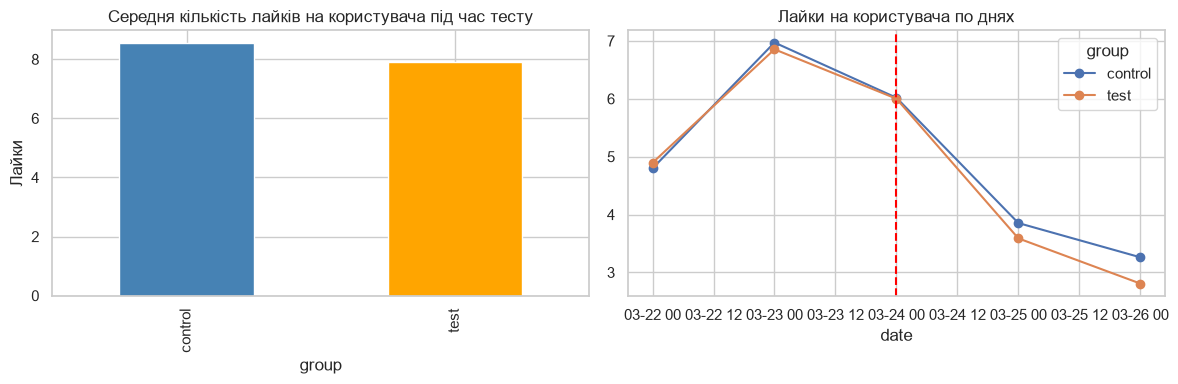

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1) Середня кількість лайків по групах
users.groupby('group')['likes_after'].mean().plot(kind='bar', ax=axes[0], color=['steelblue', 'orange'])
axes[0].set_title('Середня кількість лайків на користувача під час тесту')
axes[0].set_ylabel('Лайки')

# 2) Лайки на користувача по днях (від початку періоду «до тесту»)
d = df[df['sender_id'].isin(users['sender_id']) & (df['time_stamp'] >= PRE_START)].copy()
d['date'] = d['time_stamp'].dt.date
daily = d.groupby(['date', 'group']).size().unstack()
daily = daily.div(users['group'].value_counts(), axis=1)     # ділимо на кількість користувачів у групі
daily.plot(marker='o', ax=axes[1], title='Лайки на користувача по днях')
axes[1].axvline(TEST_START.date(), color='red', linestyle='--')    # червона лінія = старт тесту

plt.tight_layout()
plt.show()

**Що видно:** до старту тесту (червона лінія) лінії груп ідуть разом. Після старту різниця є, але невелика й нестабільна.

# 6. Висновок

**Рішення: нововведення поки не впроваджувати, а тест повторити довше.**

Чому так:
- Різниця в кількості лайків між групами **не значуща**: p-value значно більше 0.05 (у моєму запуску ≈ 0.3–0.4), а інтервал різниці включає 0.
- Знак різниці нестабільний: без обробки викидів у тесті лайків менше (≈ 7.9 проти ≈ 8.5), після обрізання викидів — трохи більше (≈ 7.2 проти ≈ 7.0).
- Частка активних у тестовій групі трохи вища (≈ 39% проти ≈ 38%), але різниця також не значуща.
- Доказів, що галочка краща за серце, немає, а ризик падіння лайків повністю виключити не можна.

Обмеження тесту:
- Тест тривав лише ≈ 2 доби (пʼятниця ввечері — вихідні), а період «до тесту» припав на будні.
- У порівняння потрапили лише користувачі, які були активні до тесту (≈ 7 тисяч із ≈ 26 тисяч).
- Даних мало, щоб помітити невеликий ефект.

Що робити далі: повторити тест щонайменше 1–2 повні тижні й окремо перевірити кількох дуже активних користувачів (можливо, це боти).

> Числа в цьому розділі я брав із виводів свого запуску.